In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
data_01 = pd.read_csv('/Volumes/KODAK/folder_02/eye_disease_prediction_model/data/raw_data/full_df.csv')
data_c = data_01.copy()

data_c.head()

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,Left-Diagnostic Keywords,Right-Diagnostic Keywords,N,D,G,C,A,H,M,O,filepath,labels,target,filename
0,0,69,Female,0_left.jpg,0_right.jpg,cataract,normal fundus,0,0,0,1,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",0_right.jpg
1,1,57,Male,1_left.jpg,1_right.jpg,normal fundus,normal fundus,1,0,0,0,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",1_right.jpg
2,2,42,Male,2_left.jpg,2_right.jpg,laser spot，moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,1,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",2_right.jpg
3,4,53,Male,4_left.jpg,4_right.jpg,macular epiretinal membrane,mild nonproliferative retinopathy,0,1,0,0,0,0,0,1,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",4_right.jpg
4,5,50,Female,5_left.jpg,5_right.jpg,moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",5_right.jpg


In [18]:
# Get the list of columns in the DataFrame

columns_list = data_c.columns.tolist()
print(columns_list)

['ID', 'Patient Age', 'Patient Sex', 'Left-Fundus', 'Right-Fundus', 'Left-Diagnostic Keywords', 'Right-Diagnostic Keywords', 'N', 'D', 'G', 'C', 'A', 'H', 'M', 'O', 'filepath', 'labels', 'target', 'filename', 'Disease Category']


In [20]:
# check the missing values 

# Show missing values per column
missing_values = data_c.isnull().sum()
print(missing_values)

ID                           0
Patient Age                  0
Patient Sex                  0
Left-Fundus                  0
Right-Fundus                 0
Left-Diagnostic Keywords     0
Right-Diagnostic Keywords    0
N                            0
D                            0
G                            0
C                            0
A                            0
H                            0
M                            0
O                            0
filepath                     0
labels                       0
target                       0
filename                     0
Disease Category             0
dtype: int64


In [21]:
data_c.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6392 entries, 0 to 6391
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   ID                         6392 non-null   int64 
 1   Patient Age                6392 non-null   int64 
 2   Patient Sex                6392 non-null   object
 3   Left-Fundus                6392 non-null   object
 4   Right-Fundus               6392 non-null   object
 5   Left-Diagnostic Keywords   6392 non-null   object
 6   Right-Diagnostic Keywords  6392 non-null   object
 7   N                          6392 non-null   int64 
 8   D                          6392 non-null   int64 
 9   G                          6392 non-null   int64 
 10  C                          6392 non-null   int64 
 11  A                          6392 non-null   int64 
 12  H                          6392 non-null   int64 
 13  M                          6392 non-null   int64 
 14  O       

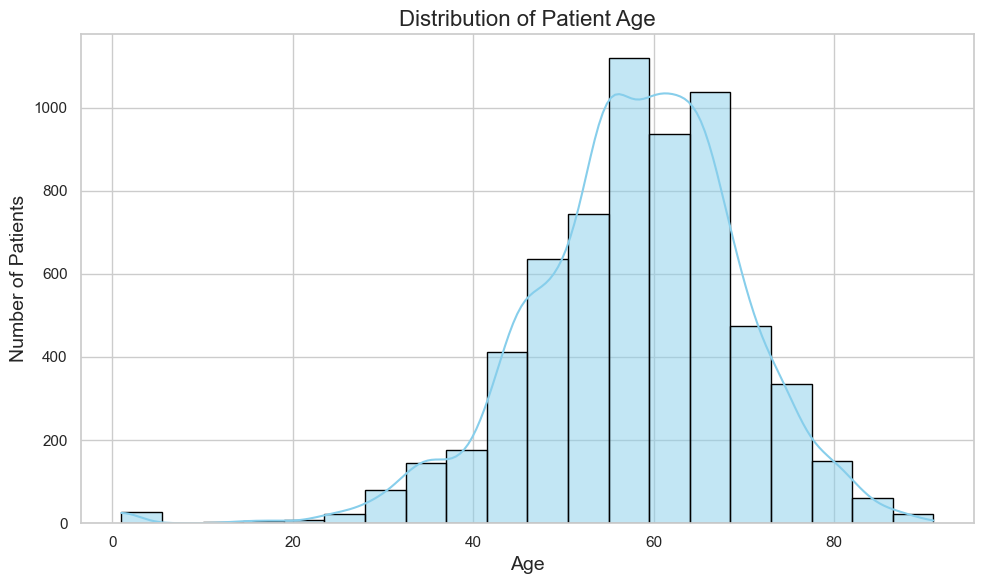

In [4]:
# Age distribution


# Remove outliers or invalid values if needed
df = data_c[data_c['Patient Age'].between(0, 120)]  # Filter to realistic human ages

# Set the style
sns.set(style="whitegrid")

# Plot
plt.figure(figsize=(10, 6))
sns.histplot(df['Patient Age'], bins=20, kde=True, color='skyblue', edgecolor='black')
plt.title('Distribution of Patient Age', fontsize=16)
plt.xlabel('Age', fontsize=14)
plt.ylabel('Number of Patients', fontsize=14)
plt.tight_layout()
plt.show()


/var/folders/ng/y3jq4z5556l47rj1150jg7jm0000gn/T/ipykernel_14866/2275280699.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Patient Sex', y='Patient Age', data=df, palette="Set2", inner="box")


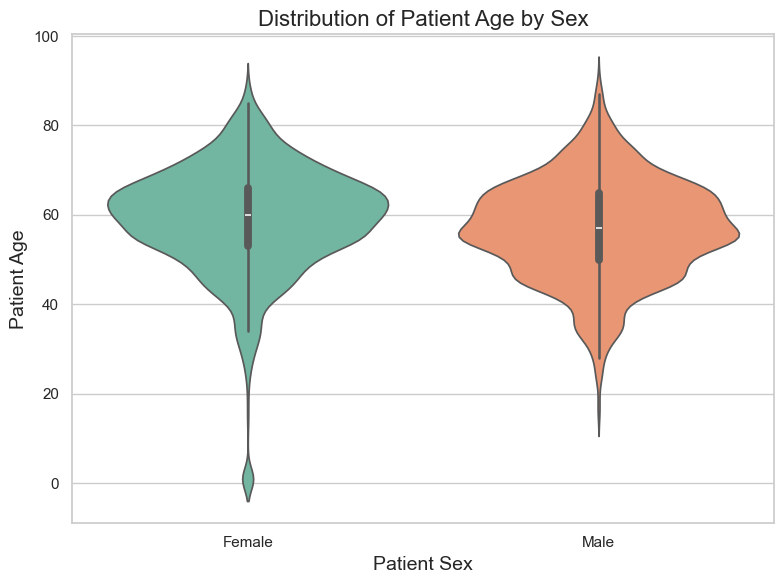

In [6]:
## distribution of ages within each sex group




# Clean the data
data_c['Patient Age'] = pd.to_numeric(data_c['Patient Age'], errors='coerce')
df = data_c.dropna(subset=['Patient Age', 'Patient Sex'])
df = data_c[data_c['Patient Age'].between(0, 120)]  # Keep only realistic ages

# Set the seaborn style
sns.set(style="whitegrid")

# Create Violin Plot
plt.figure(figsize=(8, 6))
sns.violinplot(x='Patient Sex', y='Patient Age', data=df, palette="Set2", inner="box")
plt.title('Distribution of Patient Age by Sex', fontsize=16)
plt.xlabel('Patient Sex', fontsize=14)
plt.ylabel('Patient Age', fontsize=14)
plt.tight_layout()
plt.show()



/var/folders/ng/y3jq4z5556l47rj1150jg7jm0000gn/T/ipykernel_14866/288700352.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_diseases.index, y=top_diseases.values, palette="viridis")


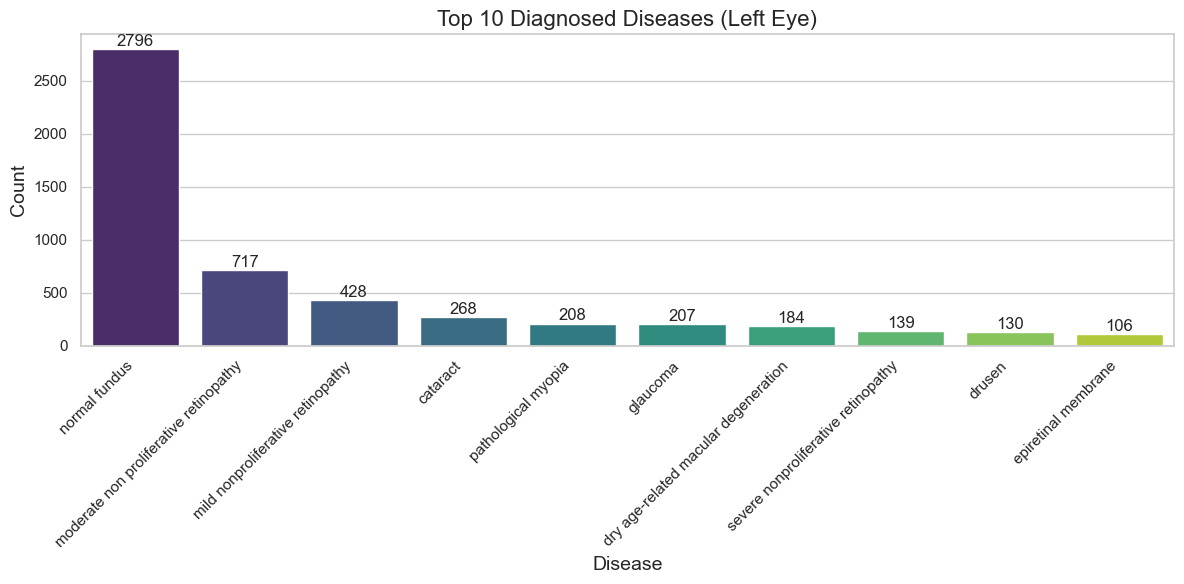

In [8]:
#  count of patients per disease

# Drop missing or NaN values in the disease column
df = data_c.dropna(subset=['Left-Diagnostic Keywords'])

# Count top 10 diseases
top_diseases = data_c['Left-Diagnostic Keywords'].value_counts().nlargest(10)

# Set style
sns.set(style="whitegrid")

# Plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=top_diseases.index, y=top_diseases.values, palette="viridis")

# Add count labels on top of bars
for i, count in enumerate(top_diseases.values):
    ax.text(i, count + 1, str(count), ha='center', va='bottom', fontsize=12)

plt.title('Top 10 Diagnosed Diseases (Left Eye)', fontsize=16)
plt.xlabel('Disease', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


/var/folders/ng/y3jq4z5556l47rj1150jg7jm0000gn/T/ipykernel_14866/4066058568.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_diseases.index, y=top_diseases.values, palette="viridis")


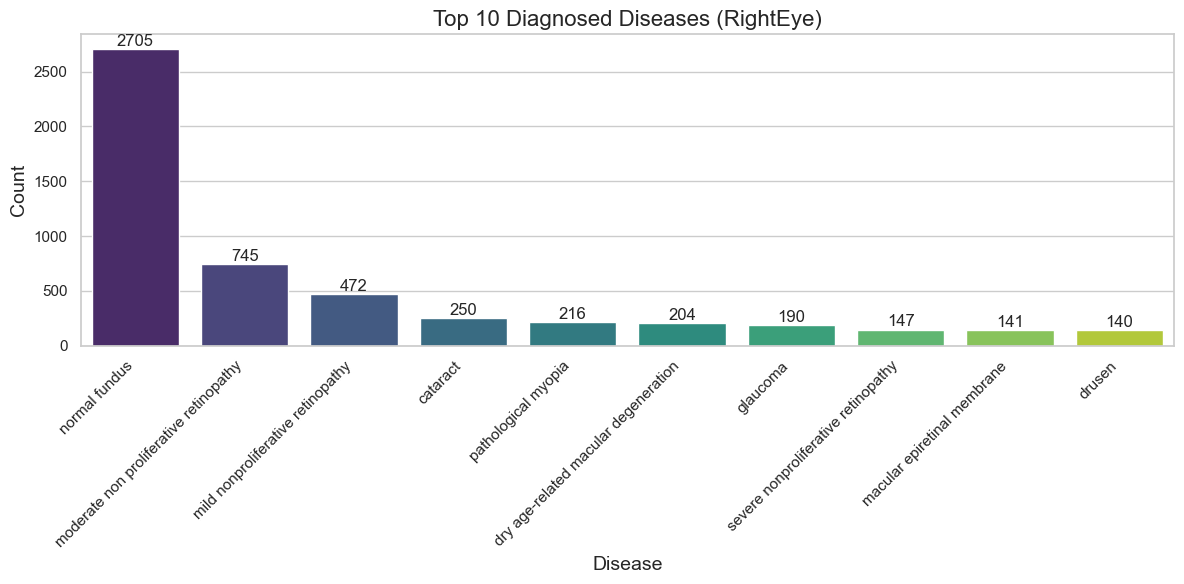

In [9]:
#  count of patients per disease

# Drop missing or NaN values in the disease column
df = data_c.dropna(subset=['Right-Diagnostic Keywords'])

# Count top 10 diseases
top_diseases = data_c['Right-Diagnostic Keywords'].value_counts().nlargest(10)

# Set style
sns.set(style="whitegrid")

# Plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=top_diseases.index, y=top_diseases.values, palette="viridis")

# Add count labels on top of bars
for i, count in enumerate(top_diseases.values):
    ax.text(i, count + 1, str(count), ha='center', va='bottom', fontsize=12)

plt.title('Top 10 Diagnosed Diseases (RightEye)', fontsize=16)
plt.xlabel('Disease', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


<Figure size 1400x600 with 0 Axes>

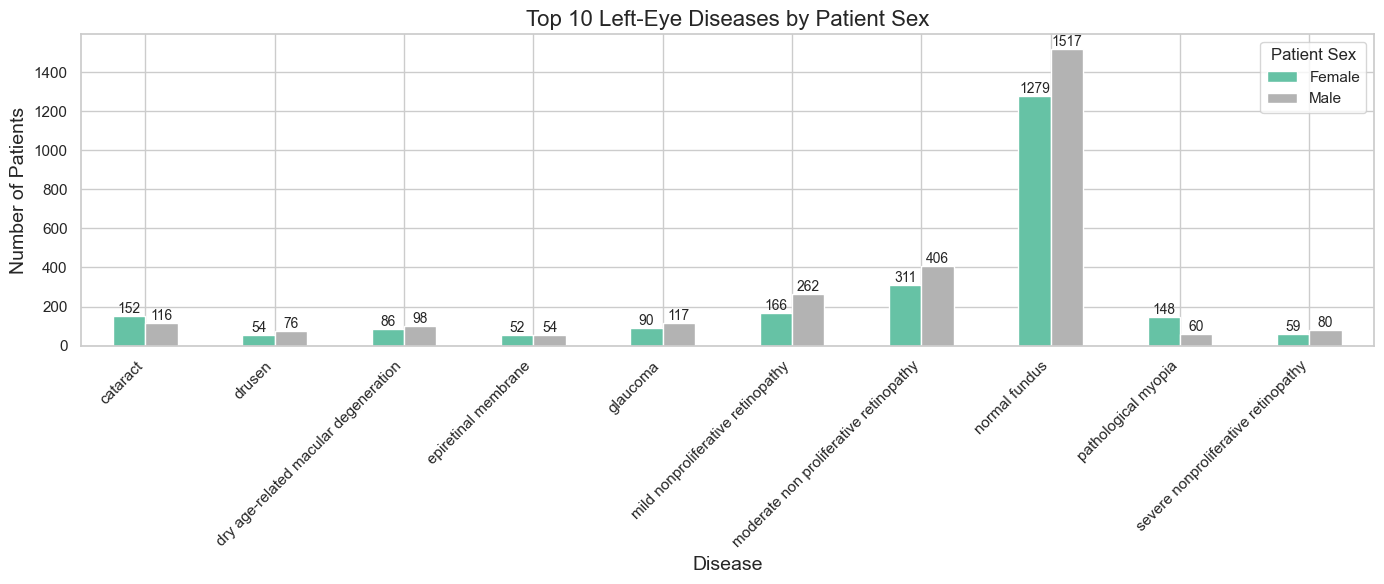

In [13]:
# Grouped Bar Plot for Top 10 Diseases by Sex



# Drop missing values
df = data_c.dropna(subset=['Patient Sex', 'Left-Diagnostic Keywords'])

# Get top 10 diseases
top_10_diseases = data_c['Left-Diagnostic Keywords'].value_counts().nlargest(10).index

# Filter for top 10
df_top = data_c[data_c['Left-Diagnostic Keywords'].isin(top_10_diseases)]

# Group by disease and sex
grouped = df_top.groupby(['Left-Diagnostic Keywords', 'Patient Sex']).size().unstack(fill_value=0)

# Set up the plot
plt.figure(figsize=(14, 6))
ax = grouped.plot(kind='bar', colormap='Set2', figsize=(14, 6))

# Add count labels on top of each bar
for i, disease in enumerate(grouped.index):
    for j, sex in enumerate(grouped.columns):
        count = grouped.loc[disease, sex]
        ax.text(i + j * 0.25 - 0.125, count + 0.5, str(count), ha='center', va='bottom', fontsize=10)

# Customize plot
plt.title('Top 10 Left-Eye Diseases by Patient Sex', fontsize=16)
plt.xlabel('Disease', fontsize=14)
plt.ylabel('Number of Patients', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Patient Sex')
plt.tight_layout()
plt.show()


<Figure size 1400x600 with 0 Axes>

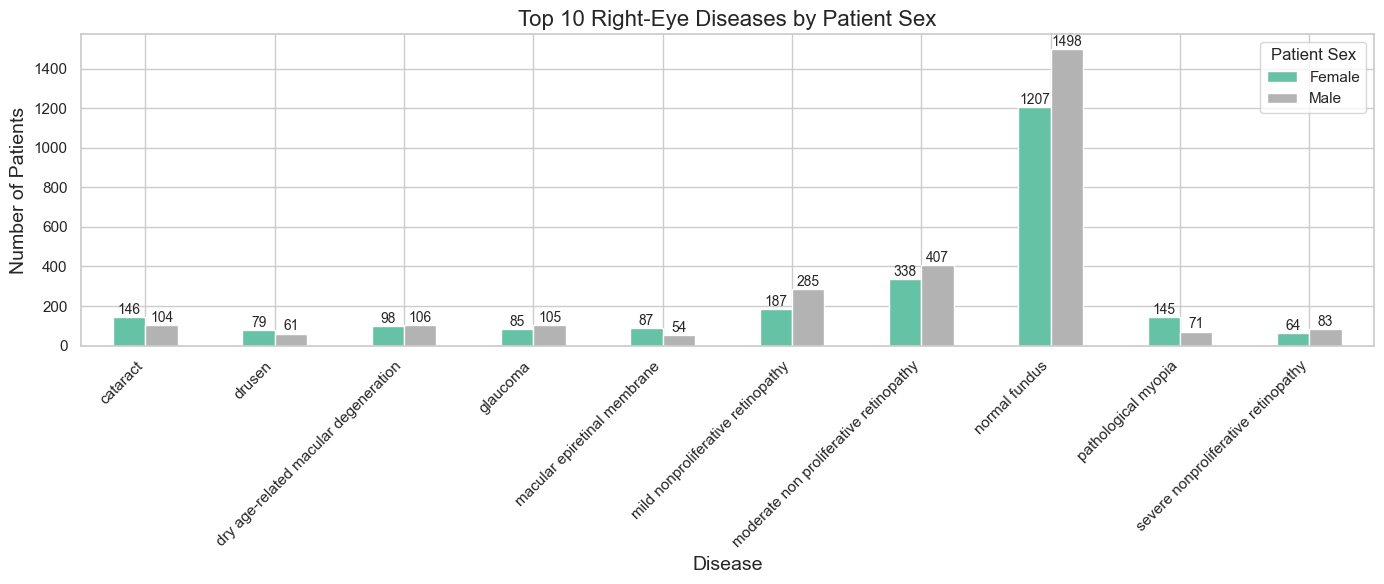

In [14]:
# Grouped Bar Plot for Top 10 Diseases by Sex


# Drop missing values
df = data_c.dropna(subset=['Patient Sex', 'Right-Diagnostic Keywords'])

# Get top 10 diseases
top_10_diseases = data_c['Right-Diagnostic Keywords'].value_counts().nlargest(10).index

# Filter for top 10
df_top = data_c[data_c['Right-Diagnostic Keywords'].isin(top_10_diseases)]

# Group by disease and sex
grouped = df_top.groupby(['Right-Diagnostic Keywords', 'Patient Sex']).size().unstack(fill_value=0)

# Set up the plot
plt.figure(figsize=(14, 6))
ax = grouped.plot(kind='bar', colormap='Set2', figsize=(14, 6))

# Add count labels on top of each bar
for i, disease in enumerate(grouped.index):
    for j, sex in enumerate(grouped.columns):
        count = grouped.loc[disease, sex]
        ax.text(i + j * 0.25 - 0.125, count + 0.5, str(count), ha='center', va='bottom', fontsize=10)

# Customize plot
plt.title('Top 10 Right-Eye Diseases by Patient Sex', fontsize=16)
plt.xlabel('Disease', fontsize=14)
plt.ylabel('Number of Patients', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Patient Sex')
plt.tight_layout()
plt.show()



/var/folders/ng/y3jq4z5556l47rj1150jg7jm0000gn/T/ipykernel_14866/2003415460.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Left-Diagnostic Keywords', y='Patient Age', data=df_top, palette="Set3")


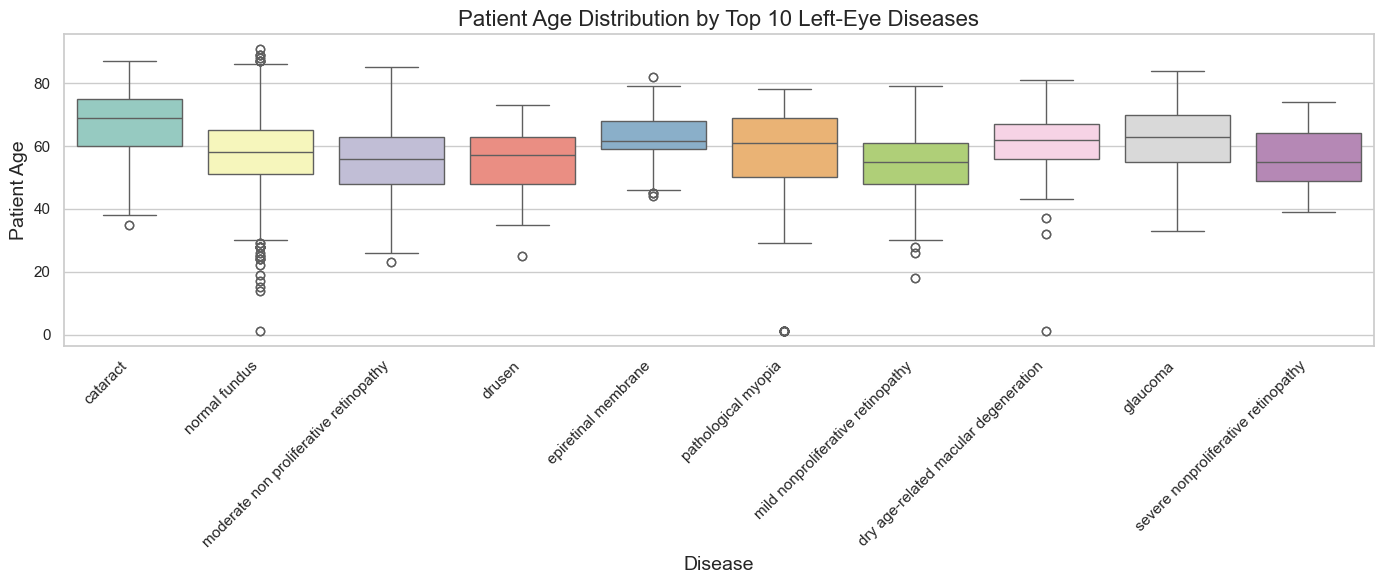

In [ ]:
# Box Plot of Patient Age by Disease

# Clean data
data_c['Patient Age'] = pd.to_numeric(df['Patient Age'], errors='coerce')
df = data_c.dropna(subset=['Patient Age', 'Left-Diagnostic Keywords'])
df = data_c[data_c['Patient Age'].between(0, 120)]  # Keep realistic ages

# Get top 10 most frequent diseases
top_10_diseases = data_c['Left-Diagnostic Keywords'].value_counts().nlargest(10).index
df_top = data_c[data_c['Left-Diagnostic Keywords'].isin(top_10_diseases)]

# Set seaborn style
sns.set(style="whitegrid")

# Create the plot
plt.figure(figsize=(14, 6))
sns.boxplot(x='Left-Diagnostic Keywords', y='Patient Age', data=df_top, palette="Set3")

# Customize
plt.title('Patient Age Distribution by Top 10 Left-Eye Diseases', fontsize=16)
plt.xlabel('Disease', fontsize=14)
plt.ylabel('Patient Age', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


/var/folders/ng/y3jq4z5556l47rj1150jg7jm0000gn/T/ipykernel_14866/2613586695.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Right-Diagnostic Keywords', y='Patient Age', data=df_top, palette="Set3")


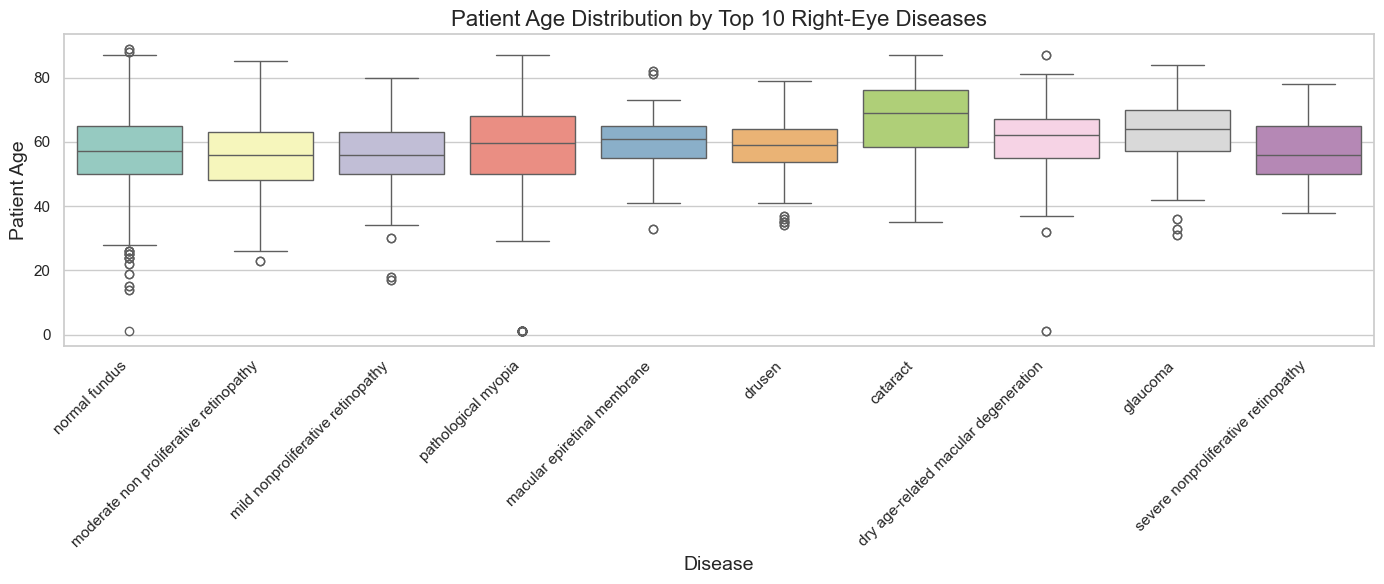

In [17]:
# Box Plot of Patient Age by Disease

# Clean data
data_c['Patient Age'] = pd.to_numeric(df['Patient Age'], errors='coerce')
df = data_c.dropna(subset=['Patient Age', 'Right-Diagnostic Keywords'])
df = data_c[data_c['Patient Age'].between(0, 120)]  # Keep realistic ages

# Get top 10 most frequent diseases
top_10_diseases = data_c['Right-Diagnostic Keywords'].value_counts().nlargest(10).index
df_top = data_c[data_c['Right-Diagnostic Keywords'].isin(top_10_diseases)]

# Set seaborn style
sns.set(style="whitegrid")

# Create the plot
plt.figure(figsize=(14, 6))
sns.boxplot(x='Right-Diagnostic Keywords', y='Patient Age', data=df_top, palette="Set3")

# Customize
plt.title('Patient Age Distribution by Top 10 Right-Eye Diseases', fontsize=16)
plt.xlabel('Disease', fontsize=14)
plt.ylabel('Patient Age', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
